In [1]:
# -*- coding: utf-8 -*-
"""flight_delay_v2.ipynb

Karamanoğlu Mehmetbey Üniversitesi — Büyük Veriye Giriş Vize Ödevi (v2 — Optimize)

Veri Seti : U.S. DOT Flight Delays (2015) — Kaggle (usdot/flight-delays)
Araçlar   : PySpark, Spark MLlib, Pandas, Matplotlib, Seaborn
Ortam     : Google Colab

"""

# ==============================================================================
# 🔷 SECTION 1: KÜTÜPHANELER VE SPARK KURULUMU
# ==============================================================================
!pip install pyspark seaborn matplotlib pandas kaggle scikit-learn > /dev/null

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import (
    col, when, sin, cos, count, avg, isnan, isnull,
    round as spark_round, sum as spark_sum, lit, row_number, desc
)
from pyspark.sql.window import Window
from pyspark.sql.types import IntegerType
from pyspark.storagelevel import StorageLevel

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from math import pi as PI
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

# --- Spark: Colab için optimize edilmiş ayarlar ---
spark = SparkSession.builder \
    .appName("FlightDelayProject_v2") \
    .config("spark.driver.memory", "8g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f"✅ Spark {spark.version} başlatıldı (v2 — optimize sürüm).")

✅ Spark 4.0.2 başlatıldı (v2 — optimize sürüm).


In [2]:
# ==============================================================================
# 🔷 SECTION 2: KAGGLE'DAN VERİ İNDİRME
# ==============================================================================
from google.colab import files
import os

print("📂 Lütfen kaggle.json dosyanızı yükleyin:")
files.upload()

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("⬇️  Veri seti indiriliyor...")
!kaggle datasets download -d usdot/flight-delays --quiet
print("📦 Zip açılıyor...")
!unzip -o flight-delays.zip -d flight_data > /dev/null
print("✅ Veri hazır: flight_data/flights.csv")

📂 Lütfen kaggle.json dosyanızı yükleyin:


Saving kaggle.json to kaggle.json
⬇️  Veri seti indiriliyor...
Dataset URL: https://www.kaggle.com/datasets/usdot/flight-delays
License(s): CC0-1.0
📦 Zip açılıyor...
✅ Veri hazır: flight_data/flights.csv



📊 Ham Veri: 5,819,079 satır × 31 kolon
root
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- AIRLINE: string (nullable = true)
 |-- FLIGHT_NUMBER: integer (nullable = true)
 |-- TAIL_NUMBER: string (nullable = true)
 |-- ORIGIN_AIRPORT: string (nullable = true)
 |-- DESTINATION_AIRPORT: string (nullable = true)
 |-- SCHEDULED_DEPARTURE: integer (nullable = true)
 |-- DEPARTURE_TIME: integer (nullable = true)
 |-- DEPARTURE_DELAY: integer (nullable = true)
 |-- TAXI_OUT: integer (nullable = true)
 |-- WHEELS_OFF: integer (nullable = true)
 |-- SCHEDULED_TIME: integer (nullable = true)
 |-- ELAPSED_TIME: integer (nullable = true)
 |-- AIR_TIME: integer (nullable = true)
 |-- DISTANCE: integer (nullable = true)
 |-- WHEELS_ON: integer (nullable = true)
 |-- TAXI_IN: integer (nullable = true)
 |-- SCHEDULED_ARRIVAL: integer (nullable = true)
 |-- ARRIVAL_TIME: integer (nullable =

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408,-22,0,0,None,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741,-9,0,0,None,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811,5,0,0,None,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756,-9,0,0,None,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259,-21,0,0,None,NaN,NaN,NaN,NaN,NaN


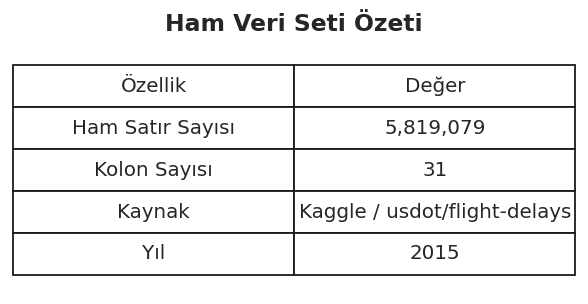

In [3]:
# ==============================================================================
# 🔷 SECTION 3: VERİYİ OKUMA
# ==============================================================================
RAW_PATH = "flight_data/flights.csv"
df_raw = spark.read.csv(RAW_PATH, header=True, inferSchema=True)

total_rows = df_raw.count()
total_cols = len(df_raw.columns)
print(f"\n📊 Ham Veri: {total_rows:,} satır × {total_cols} kolon")
df_raw.printSchema()
print("\n📋 İlk 5 Satır:")
display(df_raw.limit(5).toPandas())

# --- Özet Tablo Görseli ---
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.axis("off")
tbl_data = [
    ["Ham Satır Sayısı", f"{total_rows:,}"],
    ["Kolon Sayısı",     f"{total_cols}"],
    ["Kaynak",           "Kaggle / usdot/flight-delays"],
    ["Yıl",              "2015"],
]
t = ax.table(cellText=tbl_data, colLabels=["Özellik", "Değer"], cellLoc="center", loc="center")
t.auto_set_font_size(False); t.set_fontsize(11); t.scale(1.4, 2)
plt.title("Ham Veri Seti Özeti", fontsize=13, fontweight="bold", pad=10)
plt.tight_layout(); plt.savefig("fig01_ham_veri_ozeti.png", bbox_inches="tight"); plt.show()


🔎 Eksik değer analizi...
              Kolon  Eksik Sayı  Eksik %
CANCELLATION_REASON     5729195    98.46
LATE_AIRCRAFT_DELAY     4755640    81.72
      WEATHER_DELAY     4755640    81.72
      AIRLINE_DELAY     4755640    81.72
   AIR_SYSTEM_DELAY     4755640    81.72
     SECURITY_DELAY     4755640    81.72
       ELAPSED_TIME      105071     1.81
           AIR_TIME      105071     1.81
      ARRIVAL_DELAY      105071     1.81
          WHEELS_ON       92513     1.59
            TAXI_IN       92513     1.59
       ARRIVAL_TIME       92513     1.59
         WHEELS_OFF       89047     1.53
           TAXI_OUT       89047     1.53
     DEPARTURE_TIME       86153     1.48
    DEPARTURE_DELAY       86153     1.48
        TAIL_NUMBER       14721     0.25
     SCHEDULED_TIME           6     0.00


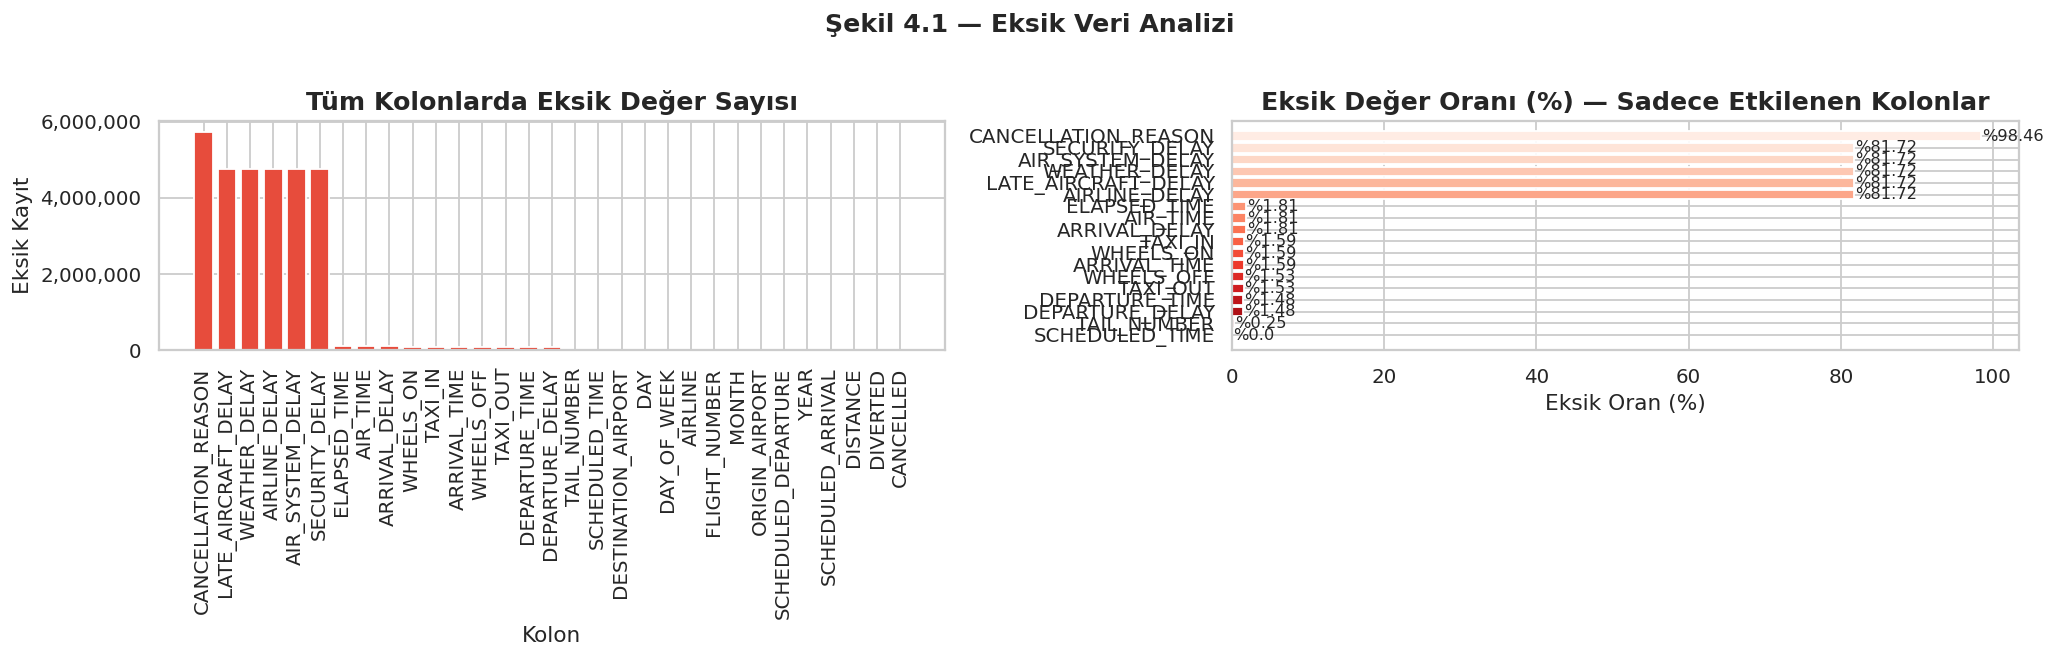

In [4]:
# ==============================================================================
# 🔷 SECTION 4: EKSİK VERİ ANALİZİ
# ==============================================================================
print("\n🔎 Eksik değer analizi...")
null_counts = df_raw.select([
    spark_sum(isnull(col(c)).cast(IntegerType())).alias(c)
    for c in df_raw.columns
]).toPandas().iloc[0].sort_values(ascending=False)

null_pct = (null_counts / total_rows * 100).round(2)
null_df = pd.DataFrame({
    "Kolon": null_counts.index,
    "Eksik Sayı": null_counts.values,
    "Eksik %": null_pct.values,
}).reset_index(drop=True)

print(null_df[null_df["Eksik Sayı"] > 0].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors_all = ["#e74c3c" if v > 0 else "#2ecc71" for v in null_counts.values]
axes[0].bar(null_counts.index, null_counts.values, color=colors_all, edgecolor="white")
axes[0].set_title("Tüm Kolonlarda Eksik Değer Sayısı")
axes[0].set_xlabel("Kolon"); axes[0].set_ylabel("Eksik Kayıt")
axes[0].tick_params(axis="x", rotation=90)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

missing_only = null_df[null_df["Eksik Sayı"] > 0].sort_values("Eksik %", ascending=True)
colors_miss = sns.color_palette("Reds_r", len(missing_only))
axes[1].barh(missing_only["Kolon"], missing_only["Eksik %"], color=colors_miss, edgecolor="white")
axes[1].set_title("Eksik Değer Oranı (%) — Sadece Etkilenen Kolonlar")
axes[1].set_xlabel("Eksik Oran (%)")
for i, (v, _) in enumerate(zip(missing_only["Eksik %"], missing_only["Kolon"])):
    axes[1].text(v + 0.1, i, f"%{v}", va="center", fontsize=9)

plt.suptitle("Şekil 4.1 — Eksik Veri Analizi", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.savefig("fig02_eksik_veri.png", bbox_inches="tight"); plt.show()


🧹 Temizleme: ham=5,819,079 → temiz=5,714,008 (silinen: 105,071)


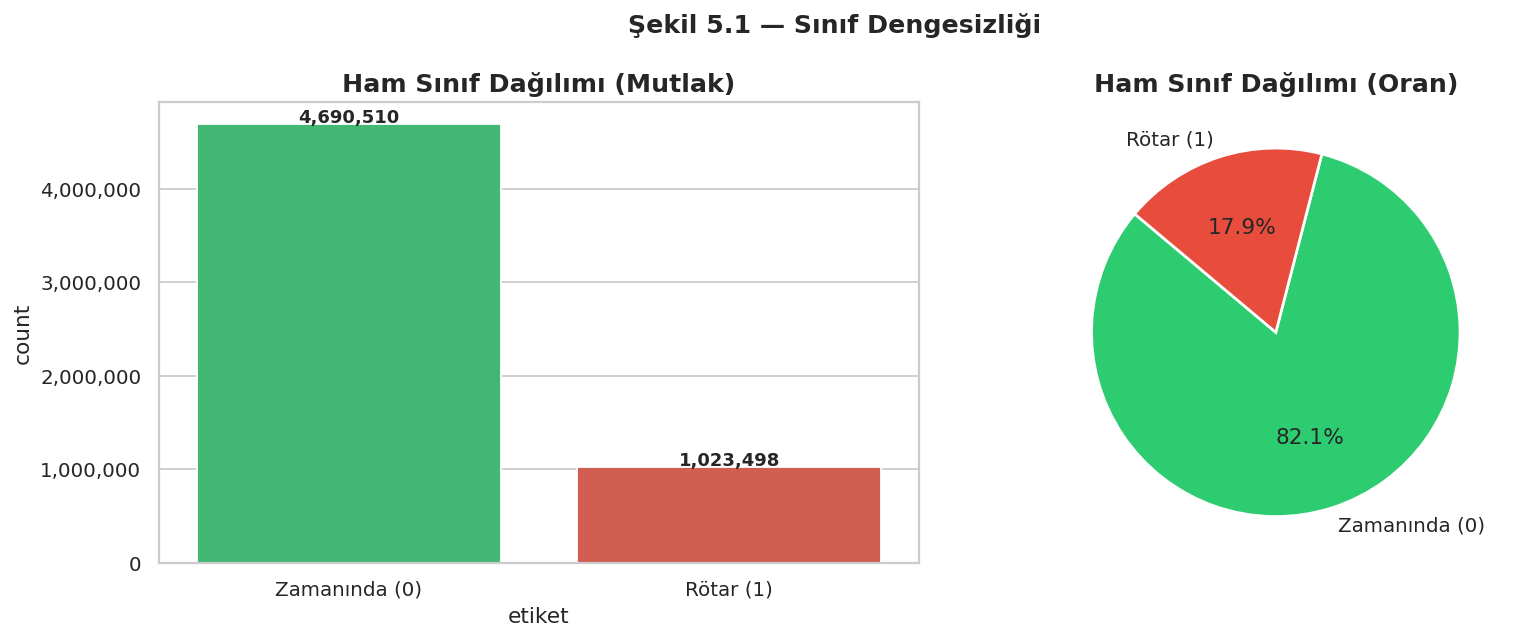

In [5]:
# ==============================================================================
# 🔷 SECTION 5: VERİ TEMİZLEME + LABEL
# ==============================================================================
SELECTED_COLS = [
    "MONTH", "DAY_OF_WEEK", "AIRLINE",
    "ORIGIN_AIRPORT", "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE", "DISTANCE", "ARRIVAL_DELAY"
]

df_clean = df_raw.select(SELECTED_COLS).dropna()
df_clean = df_clean.withColumn("label", when(col("ARRIVAL_DELAY") > 15, 1).otherwise(0))

clean_rows = df_clean.count()
dropped = total_rows - clean_rows
print(f"\n🧹 Temizleme: ham={total_rows:,} → temiz={clean_rows:,} (silinen: {dropped:,})")

# --- Sınıf dağılımı ---
label_dist = df_clean.groupBy("label").count().toPandas().sort_values("label")
label_dist["oran"] = (label_dist["count"] / label_dist["count"].sum() * 100).round(2)
label_dist["etiket"] = label_dist["label"].map({0: "Zamanında (0)", 1: "Rötar (1)"})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x="etiket", y="count", data=label_dist, palette=["#2ecc71","#e74c3c"], ax=axes[0])
axes[0].set_title("Ham Sınıf Dağılımı (Mutlak)")
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20000,
                 f"{int(bar.get_height()):,}", ha="center", fontsize=10, fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))

axes[1].pie(label_dist["count"], labels=label_dist["etiket"],
            autopct="%1.1f%%", colors=["#2ecc71","#e74c3c"],
            startangle=140, wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Ham Sınıf Dağılımı (Oran)")

plt.suptitle("Şekil 5.1 — Sınıf Dengesizliği", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("fig03_sinif_dagilimi_ham.png", bbox_inches="tight"); plt.show()

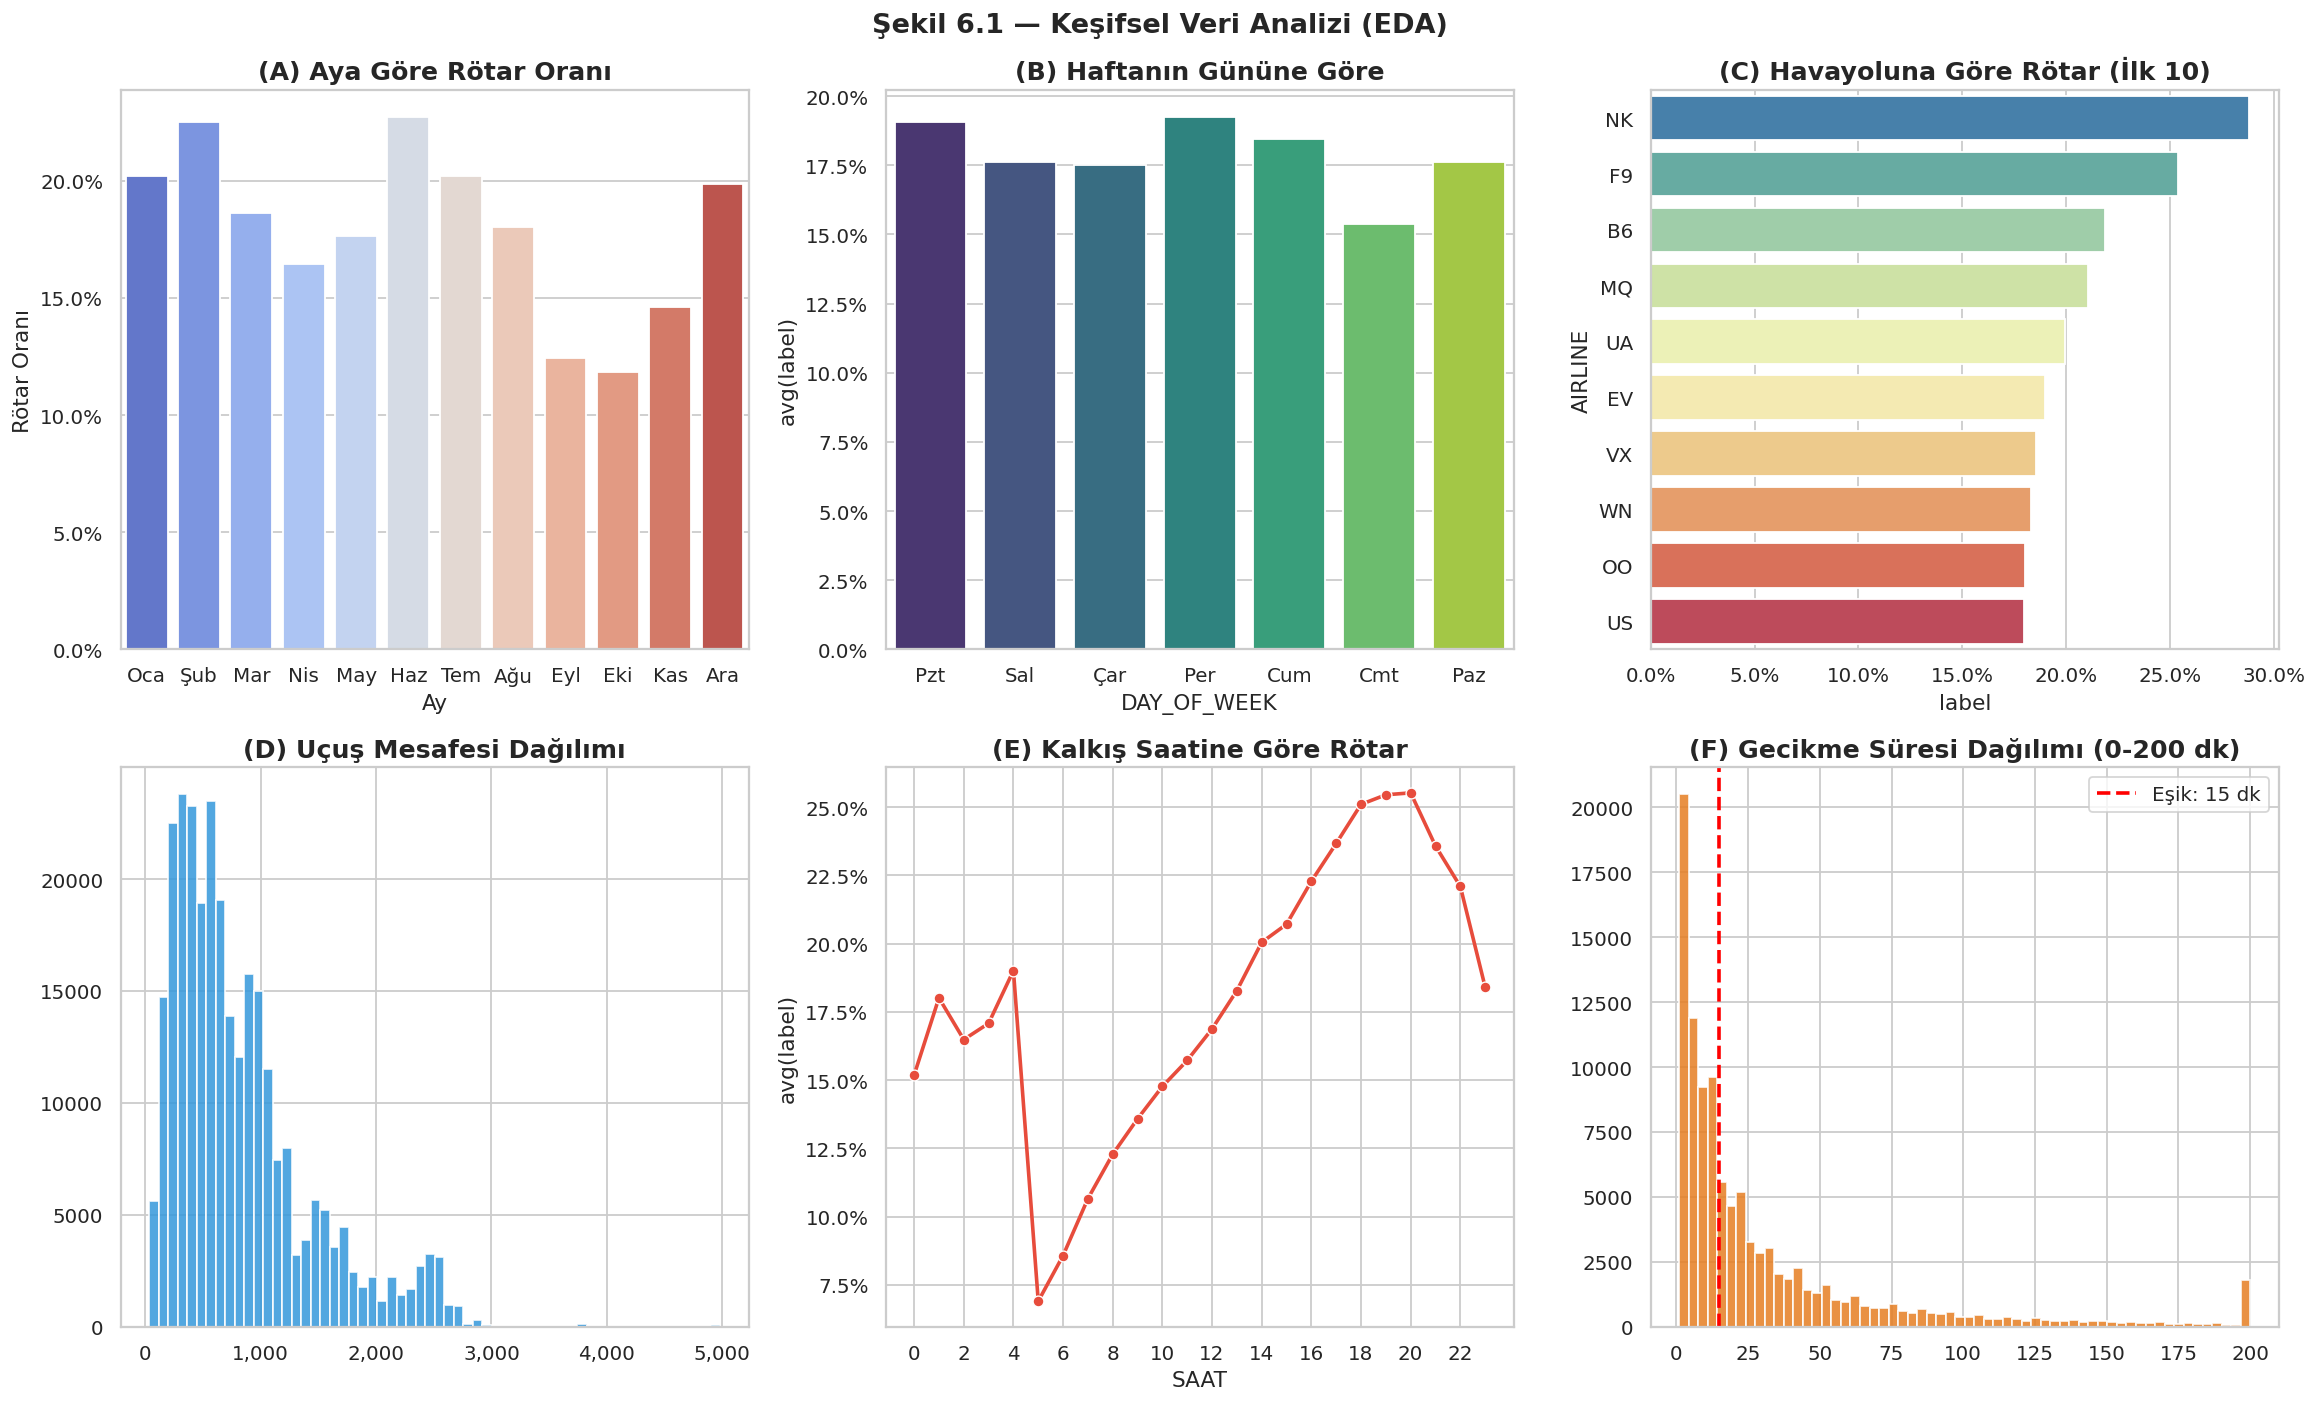

In [6]:
# ==============================================================================
# 🔷 SECTION 6: KEŞİFSEL VERİ ANALİZİ (EDA)
# ==============================================================================
df_eda = df_clean.withColumn("SAAT", (col("SCHEDULED_DEPARTURE") / 100).cast(IntegerType()))

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Şekil 6.1 — Keşifsel Veri Analizi (EDA)", fontsize=15, fontweight="bold")

monthly = df_eda.groupBy("MONTH").avg("label").toPandas().sort_values("MONTH")
monthly.columns = ["Ay", "Rötar Oranı"]
ay_labels = ["Oca","Şub","Mar","Nis","May","Haz","Tem","Ağu","Eyl","Eki","Kas","Ara"]
sns.barplot(x="Ay", y="Rötar Oranı", data=monthly, palette="coolwarm", ax=axes[0,0])
axes[0,0].set_xticklabels(ay_labels); axes[0,0].set_title("(A) Aya Göre Rötar Oranı")
axes[0,0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

daily = df_eda.groupBy("DAY_OF_WEEK").avg("label").toPandas().sort_values("DAY_OF_WEEK")
gun_labels = ["Pzt","Sal","Çar","Per","Cum","Cmt","Paz"]
sns.barplot(x="DAY_OF_WEEK", y="avg(label)", data=daily, palette="viridis", ax=axes[0,1])
axes[0,1].set_xticklabels(gun_labels); axes[0,1].set_title("(B) Haftanın Gününe Göre")
axes[0,1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

airline = (df_eda.groupBy("AIRLINE").avg("label").toPandas()
           .rename(columns={"avg(label)":"label"})
           .sort_values("label", ascending=False).head(10))
sns.barplot(x="label", y="AIRLINE", data=airline, palette="Spectral_r", ax=axes[0,2])
axes[0,2].set_title("(C) Havayoluna Göre Rötar (İlk 10)")
axes[0,2].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

dist_sample = df_eda.select("DISTANCE").sample(fraction=0.05, seed=42).toPandas()
axes[1,0].hist(dist_sample["DISTANCE"], bins=60, color="#3498db", edgecolor="white", alpha=0.85)
axes[1,0].set_title("(D) Uçuş Mesafesi Dağılımı")
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))

hourly = df_eda.groupBy("SAAT").avg("label").toPandas().sort_values("SAAT")
sns.lineplot(x="SAAT", y="avg(label)", data=hourly, marker="o",
             color="#e74c3c", linewidth=2, ax=axes[1,1])
axes[1,1].set_title("(E) Kalkış Saatine Göre Rötar")
axes[1,1].set_xticks(range(0,24,2))
axes[1,1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

delay_sample = (df_eda.filter(col("ARRIVAL_DELAY") > 0)
                .select("ARRIVAL_DELAY").sample(fraction=0.05, seed=42).toPandas())
rotar_delays = delay_sample["ARRIVAL_DELAY"].clip(upper=200)
axes[1,2].hist(rotar_delays, bins=60, color="#e67e22", edgecolor="white", alpha=0.85)
axes[1,2].axvline(15, color="red", linestyle="--", linewidth=2, label="Eşik: 15 dk")
axes[1,2].set_title("(F) Gecikme Süresi Dağılımı (0-200 dk)")
axes[1,2].legend()

plt.tight_layout(); plt.savefig("fig04_eda.png", bbox_inches="tight"); plt.show()


🛬 Top 50 havalimanı belirleniyor...
   Top 50 ORIGIN:  örn. ['ATL', 'ORD', 'DFW', 'DEN', 'LAX']
   Top 50 DEST:    örn. ['ATL', 'ORD', 'DFW', 'DEN', 'LAX']

📋 Feature Engineering sonrası kolonlar:
['MONTH', 'DAY_OF_WEEK', 'AIRLINE', 'DISTANCE', 'label', 'ORIGIN_GRP', 'DEST_GRP', 'TIME_BLOCK', 'MONTH_sin', 'MONTH_cos', 'DEP_HOUR_sin', 'DEP_HOUR_cos']

Örnek satırlar:


,MONTH,DAY_OF_WEEK,AIRLINE,DISTANCE,label,ORIGIN_GRP,DEST_GRP,TIME_BLOCK,MONTH_sin,MONTH_cos,DEP_HOUR_sin,DEP_HOUR_cos
0,1,4,AS,1448,0,OTHER,SEA,Night,0.0,1.0,0.0,1.0
1,1,4,AA,2330,0,LAX,OTHER,Night,0.0,1.0,0.0,1.0
2,1,4,US,2296,0,SFO,CLT,Night,0.0,1.0,0.0,1.0
3,1,4,AA,2342,0,LAX,MIA,Night,0.0,1.0,0.0,1.0
4,1,4,AS,1448,0,SEA,OTHER,Night,0.0,1.0,0.0,1.0


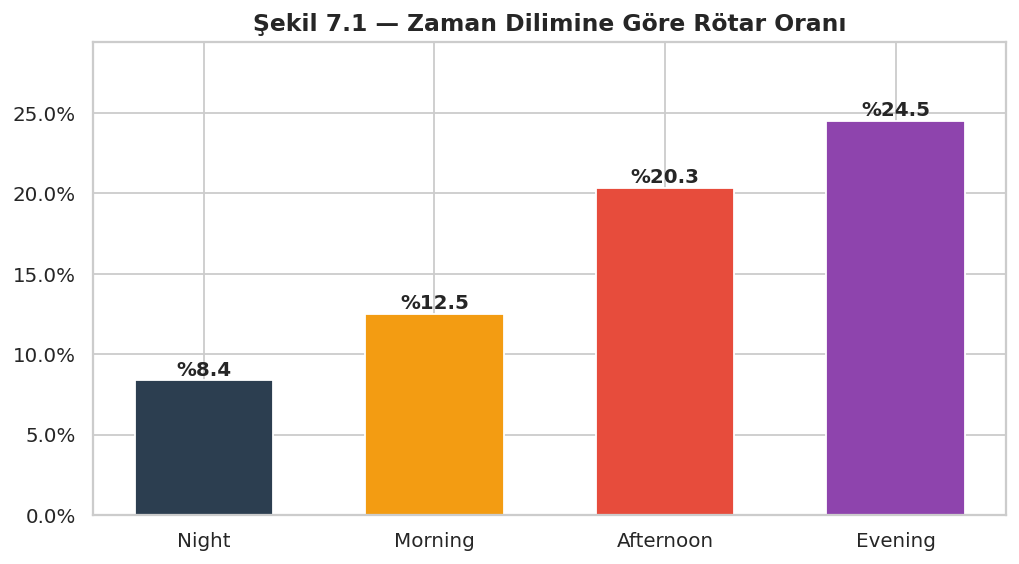

In [7]:
# ==============================================================================
# 🔷 SECTION 7: ÖZELLİK MÜHENDİSLİĞİ
# ==============================================================================
# [K1] AIRPORT CARDINALITY AZALTMA
# ──────────────────────────────────────────────────────────────────
# ORIGIN_AIRPORT ve DESTINATION_AIRPORT ~620 benzersiz değere sahip.
# OneHotEncoder bunları patlatınca feature vektörü ~1300 boyuta çıkıyor;
# RF/GBT bellek patlaması. Çözüm: TOP 50 havalimanı dışındakileri
# "OTHER" etiketine toplamak. Top 50, uçuşların ~%85'ini kapsıyor.

TOP_N_AIRPORTS = 50

def get_top_airports(df, col_name, n):
    return [r[col_name] for r in
            df.groupBy(col_name).count()
              .orderBy(desc("count")).limit(n).collect()]

print(f"\n🛬 Top {TOP_N_AIRPORTS} havalimanı belirleniyor...")
top_origins = get_top_airports(df_clean, "ORIGIN_AIRPORT", TOP_N_AIRPORTS)
top_dests   = get_top_airports(df_clean, "DESTINATION_AIRPORT", TOP_N_AIRPORTS)
print(f"   Top {TOP_N_AIRPORTS} ORIGIN:  örn. {top_origins[:5]}")
print(f"   Top {TOP_N_AIRPORTS} DEST:    örn. {top_dests[:5]}")

df_feat = df_clean \
    .withColumn("ORIGIN_GRP",
        when(col("ORIGIN_AIRPORT").isin(top_origins), col("ORIGIN_AIRPORT"))
        .otherwise(lit("OTHER"))) \
    .withColumn("DEST_GRP",
        when(col("DESTINATION_AIRPORT").isin(top_dests), col("DESTINATION_AIRPORT"))
        .otherwise(lit("OTHER"))) \
    .withColumn("TIME_BLOCK",
        when(col("SCHEDULED_DEPARTURE") < 600,  "Night")
       .when(col("SCHEDULED_DEPARTURE") < 1200, "Morning")
       .when(col("SCHEDULED_DEPARTURE") < 1800, "Afternoon")
       .otherwise("Evening")) \
    .withColumn("DEP_HOUR", (col("SCHEDULED_DEPARTURE") / 100).cast(IntegerType())) \
    .withColumn("MONTH_sin",    sin(2 * PI * (col("MONTH") - 1) / 12)) \
    .withColumn("MONTH_cos",    cos(2 * PI * (col("MONTH") - 1) / 12)) \
    .withColumn("DEP_HOUR_sin", sin(2 * PI * col("DEP_HOUR") / 24)) \
    .withColumn("DEP_HOUR_cos", cos(2 * PI * col("DEP_HOUR") / 24))

# Gereksiz kolonları düşür
df_feat = df_feat.drop(
    "ARRIVAL_DELAY", "SCHEDULED_DEPARTURE", "DEP_HOUR",
    "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"  # artık *_GRP kullanıyoruz
)

print("\n📋 Feature Engineering sonrası kolonlar:")
print(df_feat.columns)
print("\nÖrnek satırlar:")
display(df_feat.limit(5).toPandas())

# --- Zaman dilimine göre rötar ---
time_plot = df_feat.groupBy("TIME_BLOCK").avg("label").toPandas()
time_plot.columns = ["TIME_BLOCK","Rötar Oranı"]
order = ["Night","Morning","Afternoon","Evening"]
time_plot["TIME_BLOCK"] = pd.Categorical(time_plot["TIME_BLOCK"], categories=order, ordered=True)
time_plot = time_plot.sort_values("TIME_BLOCK")

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(time_plot["TIME_BLOCK"], time_plot["Rötar Oranı"],
              color=["#2c3e50","#f39c12","#e74c3c","#8e44ad"], edgecolor="white", width=0.6)
for bar, v in zip(bars, time_plot["Rötar Oranı"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f"%{v*100:.1f}", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Şekil 7.1 — Zaman Dilimine Göre Rötar Oranı", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, time_plot["Rötar Oranı"].max()*1.2)
plt.tight_layout(); plt.savefig("fig05_time_block_rotar.png", bbox_inches="tight"); plt.show()


⚖️  Dengeleme Öncesi: Rötar=1,023,498  Zamanında=4,690,510
✅ Dengeleme Sonrası: Rötar=1,023,498  Zamanında=1,025,189  (Toplam: 2,048,687)


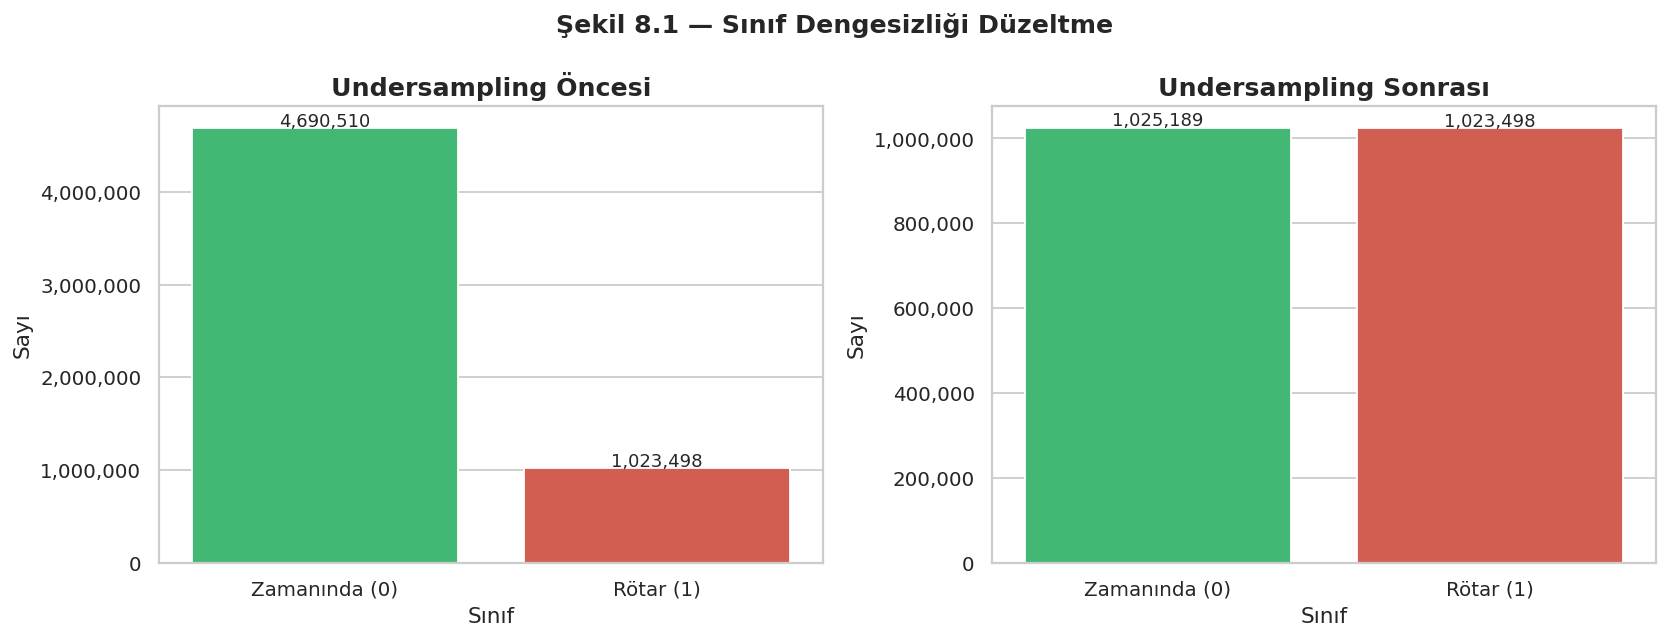

In [8]:
# ==============================================================================
# 🔷 SECTION 8: UNDERSAMPLING
# ==============================================================================
# [K8] TEK groupBy ile hem class counts hem total count — 2 job yerine 1
_counts = df_feat.groupBy("label").count().collect()
_counts_dict = {r["label"]: r["count"] for r in _counts}
rotar_count  = _counts_dict.get(1, 0)
normal_count = _counts_dict.get(0, 0)

print(f"\n⚖️  Dengeleme Öncesi: Rötar={rotar_count:,}  Zamanında={normal_count:,}")

rotar_df  = df_feat.filter(col("label") == 1)
normal_df = df_feat.filter(col("label") == 0)

fraction = min(rotar_count / normal_count, 1.0) if normal_count > 0 else 1.0
normal_sampled = normal_df.sample(withReplacement=False, fraction=fraction, seed=42)

df_balanced = rotar_df.union(normal_sampled)

# [K2] df_balanced birden çok kez kullanılacak — CACHE
df_balanced = df_balanced.persist(StorageLevel.MEMORY_AND_DISK)

# Tek count ile hem doğrulama hem metric
bal_counts = df_balanced.groupBy("label").count().collect()
bal_dict = {r["label"]: r["count"] for r in bal_counts}
balanced_count = sum(bal_dict.values())

print(f"✅ Dengeleme Sonrası: Rötar={bal_dict.get(1,0):,}  Zamanında={bal_dict.get(0,0):,}  (Toplam: {balanced_count:,})")

# --- Önce/Sonra grafik ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
before = pd.DataFrame({"Sınıf":["Zamanında (0)","Rötar (1)"], "Sayı":[normal_count, rotar_count]})
sns.barplot(x="Sınıf", y="Sayı", data=before, palette=["#2ecc71","#e74c3c"], ax=axes[0])
axes[0].set_title("Undersampling Öncesi")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+15000,
                 f"{int(bar.get_height()):,}", ha="center", fontsize=10)

after = pd.DataFrame({"Sınıf":["Zamanında (0)","Rötar (1)"],
                      "Sayı":[bal_dict.get(0,0), bal_dict.get(1,0)]})
sns.barplot(x="Sınıf", y="Sayı", data=after, palette=["#2ecc71","#e74c3c"], ax=axes[1])
axes[1].set_title("Undersampling Sonrası")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
                 f"{int(bar.get_height()):,}", ha="center", fontsize=10)

plt.suptitle("Şekil 8.1 — Sınıf Dengesizliği Düzeltme", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("fig06_undersampling.png", bbox_inches="tight"); plt.show()


✂️  Train: 1,639,250  |  Test: 409,437


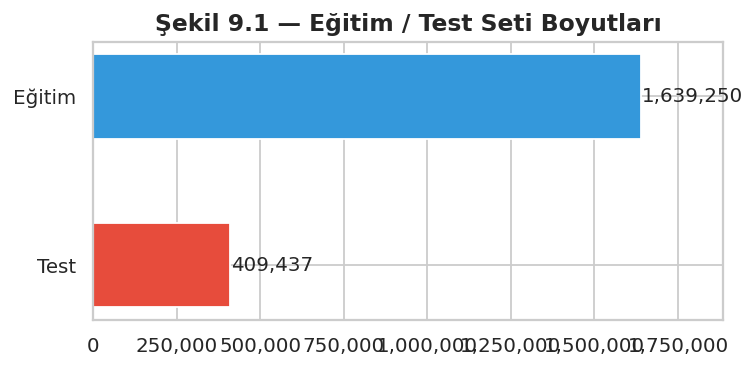

In [9]:
# ==============================================================================
# 🔷 SECTION 9: TRAIN / TEST BÖLME
# ==============================================================================
train_df, test_df = df_balanced.randomSplit([0.8, 0.2], seed=42)
train_df = train_df.persist(StorageLevel.MEMORY_AND_DISK)
test_df  = test_df.persist(StorageLevel.MEMORY_AND_DISK)

train_count = train_df.count()
test_count  = test_df.count()
print(f"\n✂️  Train: {train_count:,}  |  Test: {test_count:,}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(["Test","Eğitim"], [test_count, train_count],
        color=["#e74c3c","#3498db"], edgecolor="white", height=0.5)
for rect, v in zip(ax.patches, [test_count, train_count]):
    ax.text(rect.get_width()+2000, rect.get_y()+rect.get_height()/2,
            f"{v:,}", va="center", fontsize=11)
ax.set_title("Şekil 9.1 — Eğitim / Test Seti Boyutları", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax.set_xlim(0, train_count*1.15)
plt.tight_layout(); plt.savefig("fig07_train_test_split.png", bbox_inches="tight"); plt.show()

In [10]:
# ==============================================================================
# 🔷 SECTION 10: İKİ PIPELINE — LR ve AĞAÇ-TEMELLİ MODELLER İÇİN AYRI
# ==============================================================================
# [K3] ANAHTAR FIKIR: RF/GBT kategorik özellikleri HAM INDEX olarak iyi işler
#      (OneHot gerekmez). Böylece feature vektörü 1300 → ~10 boyuta düşer,
#      RF maxDepth=5 yerine maxDepth=12-15 kullanılabilir
#
# LR ise ölçek duyarlı olduğundan OneHotEncoder + StandardScaler gerekir.
# Bu yüzden iki ayrı pipeline kurulacak.

from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

cat_cols     = ["AIRLINE", "ORIGIN_GRP", "DEST_GRP", "TIME_BLOCK"]
numeric_cols = ["DAY_OF_WEEK", "DISTANCE", "MONTH_sin", "MONTH_cos",
                "DEP_HOUR_sin", "DEP_HOUR_cos"]

# --- Ortak: String Indexer (her iki pipeline paylaşır) ---
indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in cat_cols
]

# --- LR Pipeline: OHE + Scaler ---
encoders_lr = [
    OneHotEncoder(inputCol=c + "_idx", outputCol=c + "_ohe")
    for c in cat_cols
]
assembler_lr = VectorAssembler(
    inputCols=[c + "_ohe" for c in cat_cols] + numeric_cols,
    outputCol="features_raw"
)
scaler_lr = StandardScaler(
    inputCol="features_raw", outputCol="features",
    withStd=True, withMean=False  # sparse vektörlerle mean=False gerek
)
pipeline_lr = Pipeline(stages=indexers + encoders_lr + [assembler_lr, scaler_lr])

# --- Ağaç Pipeline: SADECE Index (OHE YOK) ---
assembler_tree = VectorAssembler(
    inputCols=[c + "_idx" for c in cat_cols] + numeric_cols,
    outputCol="features"
)
pipeline_tree = Pipeline(stages=indexers + [assembler_tree])

print("⚙️  LR Pipeline fit ediliyor (OHE + Scaler)...")
pipeline_lr_model = pipeline_lr.fit(train_df)

print("⚙️  Ağaç Pipeline fit ediliyor (sadece Index)...")
pipeline_tree_model = pipeline_tree.fit(train_df)

# Transforms
train_lr   = pipeline_lr_model.transform(train_df).select("features","label").persist(StorageLevel.MEMORY_AND_DISK)
test_lr    = pipeline_lr_model.transform(test_df).select("features","label").persist(StorageLevel.MEMORY_AND_DISK)
train_tree = pipeline_tree_model.transform(train_df).select("features","label").persist(StorageLevel.MEMORY_AND_DISK)
test_tree  = pipeline_tree_model.transform(test_df).select("features","label").persist(StorageLevel.MEMORY_AND_DISK)

# Boyutları karşılaştır
lr_size   = train_lr.select("features").first()[0].size
tree_size = train_tree.select("features").first()[0].size
print(f"\n📐 Feature vektör boyutları:")
print(f"   LR pipeline   (OHE+Scaler) : {lr_size}")
print(f"   Tree pipeline (sadece Idx) : {tree_size}  ← {lr_size - tree_size} kat daha hafif!")

⚙️  LR Pipeline fit ediliyor (OHE + Scaler)...
⚙️  Ağaç Pipeline fit ediliyor (sadece Index)...

📐 Feature vektör boyutları:
   LR pipeline   (OHE+Scaler) : 126
   Tree pipeline (sadece Idx) : 10  ← 116 kat daha hafif!


In [11]:
# ==============================================================================
# 🔷 SECTION 11: MODEL 1 — LOGISTIC REGRESSION (scaled features)
# ==============================================================================
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    labelCol="label", featuresCol="features",
    maxIter=100, regParam=0.01, elasticNetParam=0.0
)
print("🔄 Logistic Regression eğitiliyor...")
lr_model = lr.fit(train_lr)
lr_pred = lr_model.transform(test_lr).persist(StorageLevel.MEMORY_AND_DISK)
print("✅ LR tamamlandı.")

🔄 Logistic Regression eğitiliyor...
✅ LR tamamlandı.


In [12]:
# ==============================================================================
# 🔷 SECTION 12: MODEL 2 — RANDOM FOREST
# ==============================================================================
# [K3] OHE bypass edildiği için artık RAM rahat. Derinlik ve ağaç sayısı arttı.
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="label", featuresCol="features",
    numTrees=60,       # 60
    maxDepth=12,       # 12
    maxBins=128,
    subsamplingRate=0.8,
    featureSubsetStrategy="sqrt",
    seed=42
)
print("🔄 Random Forest eğitiliyor (numTrees=60, maxDepth=12)...")
rf_model = rf.fit(train_tree)
rf_pred = rf_model.transform(test_tree).persist(StorageLevel.MEMORY_AND_DISK)
print("✅ RF tamamlandı.")

🔄 Random Forest eğitiliyor (numTrees=60, maxDepth=12)...
✅ RF tamamlandı.


In [14]:
# ==============================================================================
# 🔷 SECTION 13: MODEL 3 — GBT (GRADIENT BOOSTED TREES)  ★YENİ★
# ==============================================================================

from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    labelCol="label", featuresCol="features",
    maxIter=50,        # boosting round sayısı
    maxDepth=6,        # her ağaç sığ (boosting için uygun)
    stepSize=0.1,      # learning rate
    maxBins=128,
    subsamplingRate=0.8,
    seed=42
)
print("🔄 GBT eğitiliyor (maxIter=50, maxDepth=6)... bu biraz uzun sürer.")
gbt_model = gbt.fit(train_tree)
gbt_pred  = gbt_model.transform(test_tree).persist(StorageLevel.MEMORY_AND_DISK)
print("✅ GBT tamamlandı.")

🔄 GBT eğitiliyor (maxIter=50, maxDepth=6)... bu biraz uzun sürer.
✅ GBT tamamlandı.


In [16]:
# ==============================================================================
# 🔷 SECTION 14: AUC
# ==============================================================================
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)
lr_auc  = evaluator_auc.evaluate(lr_pred)
rf_auc  = evaluator_auc.evaluate(rf_pred)
gbt_auc = evaluator_auc.evaluate(gbt_pred)

print(f"\n📈 AUC Sonuçları:")
print(f"   Logistic Regression : {lr_auc:.4f}")
print(f"   Random Forest       : {rf_auc:.4f}")
print(f"   GBT (★yeni★)        : {gbt_auc:.4f}")


📈 AUC Sonuçları:
   Logistic Regression : 0.6426
   Random Forest       : 0.6721
   GBT (★yeni★)        : 0.6858


In [17]:
# ==============================================================================
# 🔷 SECTION 15: PRECISION / RECALL / F1
# ==============================================================================
def compute_metrics(pred_df, model_name, auc_value):
    """Tek groupBy — TP/TN/FP/FN."""
    cm = (pred_df.groupBy("label","prediction").count().toPandas())
    def g(l,p):
        r = cm[(cm["label"]==l)&(cm["prediction"]==p)]
        return int(r["count"].values[0]) if len(r)>0 else 0
    tp, tn, fp, fn = g(1,1), g(0,0), g(0,1), g(1,0)
    prec = tp/(tp+fp) if tp+fp>0 else 0
    rec  = tp/(tp+fn) if tp+fn>0 else 0
    f1   = 2*prec*rec/(prec+rec) if prec+rec>0 else 0
    acc  = (tp+tn)/(tp+tn+fp+fn) if tp+tn+fp+fn>0 else 0
    print(f"\n📊 {model_name}")
    print(f"   TP={tp:,} TN={tn:,} FP={fp:,} FN={fn:,}")
    print(f"   Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  Acc={acc:.4f}")
    return {"model":model_name,"TP":tp,"TN":tn,"FP":fp,"FN":fn,
            "Precision":prec,"Recall":rec,"F1":f1,"Accuracy":acc,"AUC":auc_value}

lr_metrics  = compute_metrics(lr_pred,  "Logistic Regression", lr_auc)
rf_metrics  = compute_metrics(rf_pred,  "Random Forest",       rf_auc)
gbt_metrics = compute_metrics(gbt_pred, "GBT",                 gbt_auc)


📊 Logistic Regression
   TP=129,109 TN=118,872 FP=85,698 FN=75,758
   Precision=0.6010  Recall=0.6302  F1=0.6153  Acc=0.6057

📊 Random Forest
   TP=135,857 TN=119,715 FP=84,855 FN=69,010
   Precision=0.6155  Recall=0.6631  F1=0.6385  Acc=0.6242

📊 GBT
   TP=132,870 TN=126,632 FP=77,938 FN=71,997
   Precision=0.6303  Recall=0.6486  F1=0.6393  Acc=0.6338


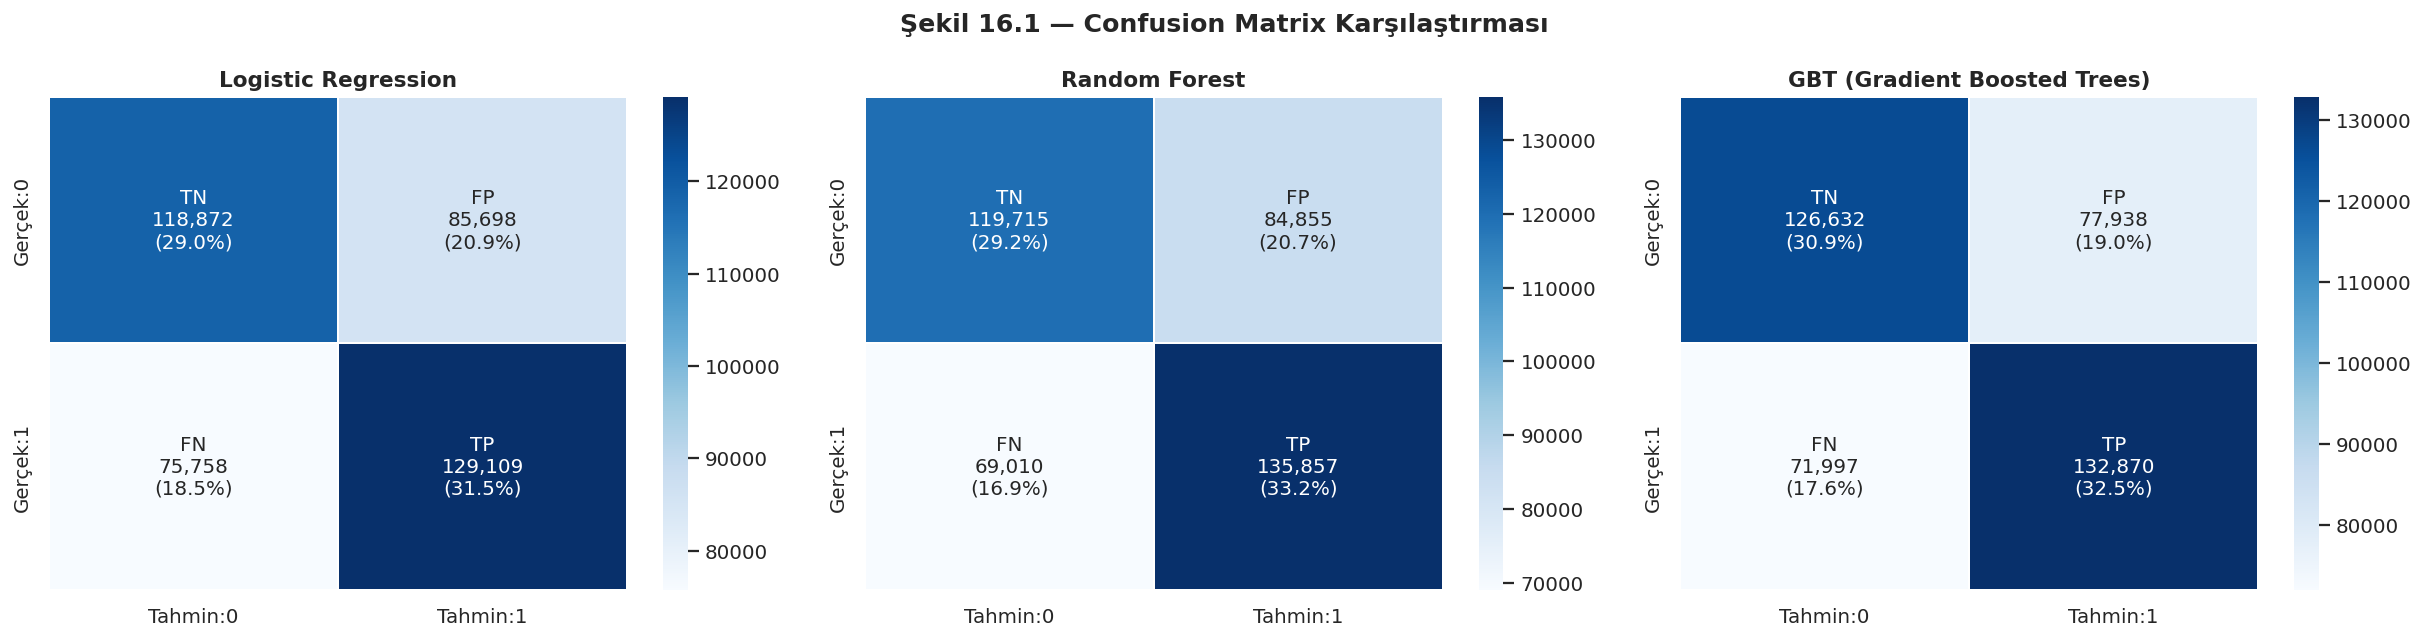

In [18]:
# ==============================================================================
# 🔷 SECTION 16: CONFUSION MATRIX (3 MODEL)
# ==============================================================================
def plot_cm(m, ax, title):
    cm = np.array([[m["TN"],m["FP"]],[m["FN"],m["TP"]]])
    tot = cm.sum(); cp = cm/tot*100
    lbl = np.array([
        [f"TN\n{cm[0,0]:,}\n({cp[0,0]:.1f}%)", f"FP\n{cm[0,1]:,}\n({cp[0,1]:.1f}%)"],
        [f"FN\n{cm[1,0]:,}\n({cp[1,0]:.1f}%)", f"TP\n{cm[1,1]:,}\n({cp[1,1]:.1f}%)"]])
    sns.heatmap(cm, annot=lbl, fmt="", cmap="Blues",
                xticklabels=["Tahmin:0","Tahmin:1"],
                yticklabels=["Gerçek:0","Gerçek:1"],
                linewidths=1, linecolor="white", ax=ax, annot_kws={"size":11})
    ax.set_title(title, fontsize=12, fontweight="bold")

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
plot_cm(lr_metrics,  axes[0], "Logistic Regression")
plot_cm(rf_metrics,  axes[1], "Random Forest")
plot_cm(gbt_metrics, axes[2], "GBT (Gradient Boosted Trees)")
plt.suptitle("Şekil 16.1 — Confusion Matrix Karşılaştırması", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("fig08_confusion_matrix.png", bbox_inches="tight"); plt.show()

📉 ROC verileri...


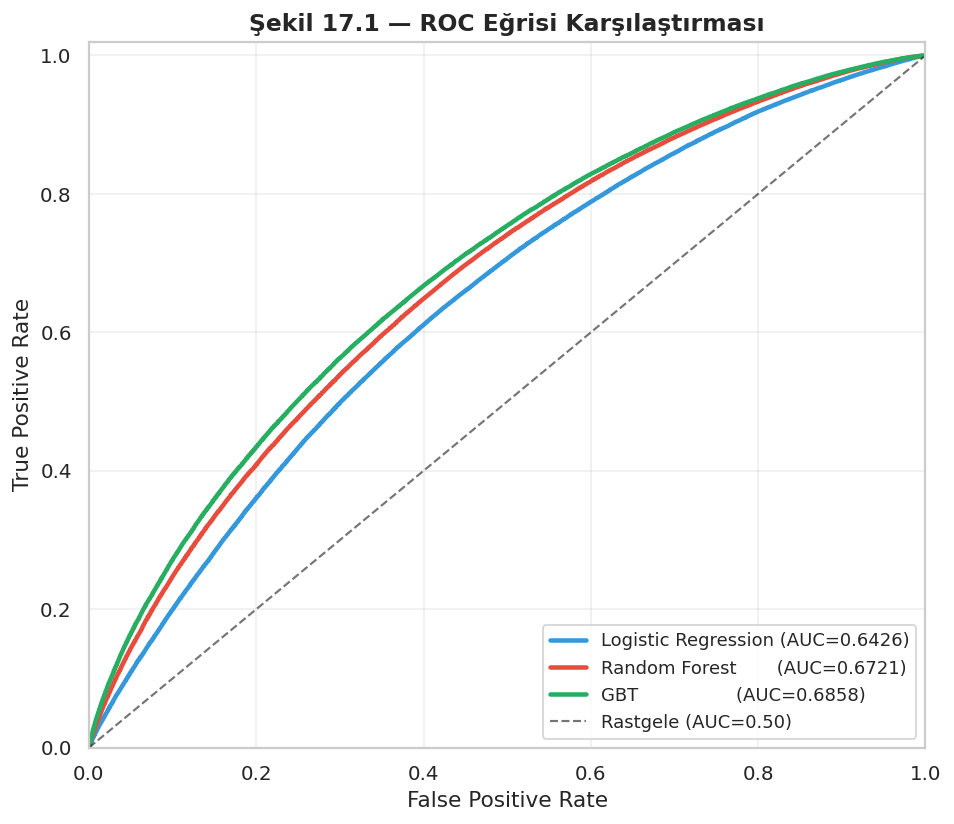

In [19]:
# ==============================================================================
# 🔷 SECTION 17: ROC EĞRİSİ (3 MODEL)
# ==============================================================================
from sklearn.metrics import roc_curve

def get_roc(pred_df):
    pdf = pred_df.select("label","probability").toPandas()
    s = pdf["probability"].apply(lambda v: float(v[1]))
    y = pdf["label"].astype(int)
    fpr, tpr, _ = roc_curve(y, s)
    return fpr, tpr

print("📉 ROC verileri...")
lr_fpr, lr_tpr   = get_roc(lr_pred)
rf_fpr, rf_tpr   = get_roc(rf_pred)
gbt_fpr, gbt_tpr = get_roc(gbt_pred)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.plot(lr_fpr,  lr_tpr,  color="#3498db", linewidth=2.5, label=f"Logistic Regression (AUC={lr_auc:.4f})")
ax.plot(rf_fpr,  rf_tpr,  color="#e74c3c", linewidth=2.5, label=f"Random Forest       (AUC={rf_auc:.4f})")
ax.plot(gbt_fpr, gbt_tpr, color="#27ae60", linewidth=2.5, label=f"GBT                 (AUC={gbt_auc:.4f})")
ax.plot([0,1],[0,1], "k--", linewidth=1.2, alpha=0.6, label="Rastgele (AUC=0.50)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Şekil 17.1 — ROC Eğrisi Karşılaştırması", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("fig09_roc_curve.png", bbox_inches="tight"); plt.show()


🎯 Threshold Tuning — en iyi model (GBT) için optimal F1 eşiği aranıyor...
   Varsayılan eşik 0.50 → F1 = 0.6393
   EN İYİ eşik 0.35   → F1 = 0.6872  (+4.79 puan)


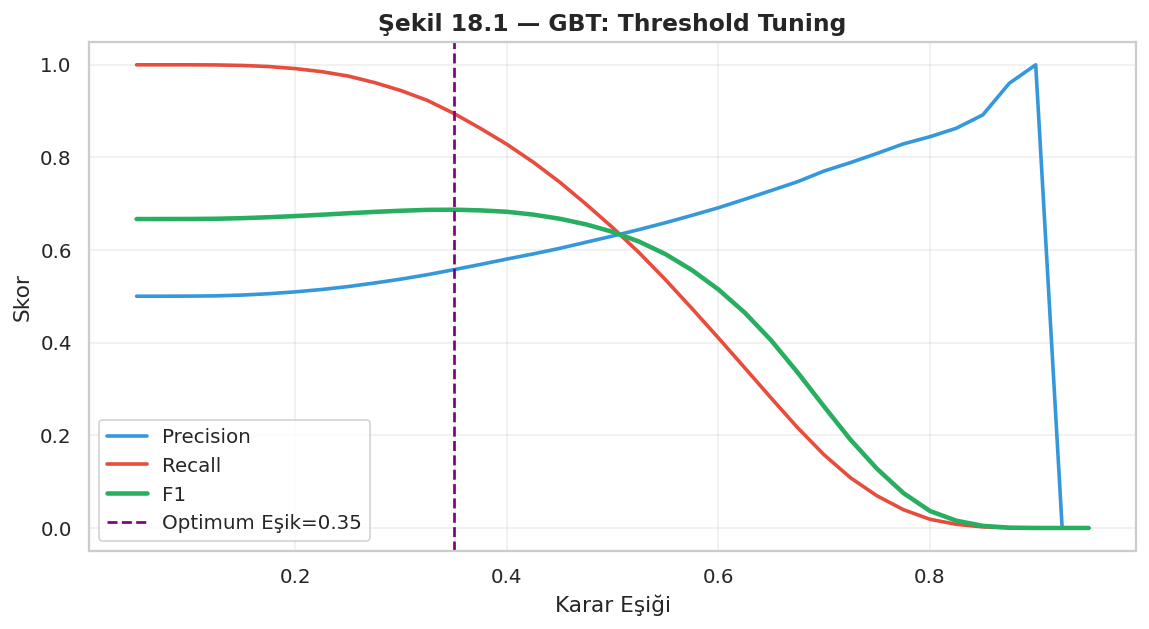

   🎯 Optimum eşikli GBT: Precision=0.5577 Recall=0.8949 F1=0.6872 Acc=0.5923


In [20]:
# ==============================================================================
# 🔷 SECTION 18: THRESHOLD TUNING  ★YENİ★
# ==============================================================================
# [K7] Default eşik 0.5. Ama F1 için optimum eşik nadiren 0.5'tir.
#      En iyi modelin (genelde GBT) eşiğini tarayıp F1-optimal noktayı bulalım.
print("\n🎯 Threshold Tuning — en iyi model (GBT) için optimal F1 eşiği aranıyor...")

scores_df = gbt_pred.select("label","probability").toPandas()
scores = scores_df["probability"].apply(lambda v: float(v[1])).values
y_true = scores_df["label"].astype(int).values

thresholds = np.linspace(0.05, 0.95, 37)
f1_list, prec_list, rec_list = [], [], []
for t in thresholds:
    y_pred = (scores >= t).astype(int)
    tp = int(((y_pred==1) & (y_true==1)).sum())
    fp = int(((y_pred==1) & (y_true==0)).sum())
    fn = int(((y_pred==0) & (y_true==1)).sum())
    p = tp/(tp+fp) if tp+fp>0 else 0
    r = tp/(tp+fn) if tp+fn>0 else 0
    f = 2*p*r/(p+r) if p+r>0 else 0
    f1_list.append(f); prec_list.append(p); rec_list.append(r)

best_idx = int(np.argmax(f1_list))
best_t   = thresholds[best_idx]
best_f1  = f1_list[best_idx]
print(f"   Varsayılan eşik 0.50 → F1 = {gbt_metrics['F1']:.4f}")
print(f"   EN İYİ eşik {best_t:.2f}   → F1 = {best_f1:.4f}  (+{(best_f1-gbt_metrics['F1'])*100:.2f} puan)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, prec_list, color="#3498db", label="Precision", linewidth=2)
ax.plot(thresholds, rec_list,  color="#e74c3c", label="Recall",    linewidth=2)
ax.plot(thresholds, f1_list,   color="#27ae60", label="F1",        linewidth=2.5)
ax.axvline(best_t, color="purple", linestyle="--", linewidth=1.5, label=f"Optimum Eşik={best_t:.2f}")
ax.set_xlabel("Karar Eşiği"); ax.set_ylabel("Skor")
ax.set_title("Şekil 18.1 — GBT: Threshold Tuning", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("fig10_threshold_tuning.png", bbox_inches="tight"); plt.show()

# Optimum eşik ile yeniden tahmin
y_opt = (scores >= best_t).astype(int)
tp = int(((y_opt==1)&(y_true==1)).sum())
tn = int(((y_opt==0)&(y_true==0)).sum())
fp = int(((y_opt==1)&(y_true==0)).sum())
fn = int(((y_opt==0)&(y_true==1)).sum())
prec_opt = tp/(tp+fp); rec_opt = tp/(tp+fn)
f1_opt   = 2*prec_opt*rec_opt/(prec_opt+rec_opt)
acc_opt  = (tp+tn)/(tp+tn+fp+fn)
gbt_opt_metrics = {"model":"GBT (opt-threshold)","TP":tp,"TN":tn,"FP":fp,"FN":fn,
                   "Precision":prec_opt,"Recall":rec_opt,"F1":f1_opt,
                   "Accuracy":acc_opt,"AUC":gbt_auc}
print(f"   🎯 Optimum eşikli GBT: Precision={prec_opt:.4f} Recall={rec_opt:.4f} F1={f1_opt:.4f} Acc={acc_opt:.4f}")


🌲 Feature Importance — Random Forest:


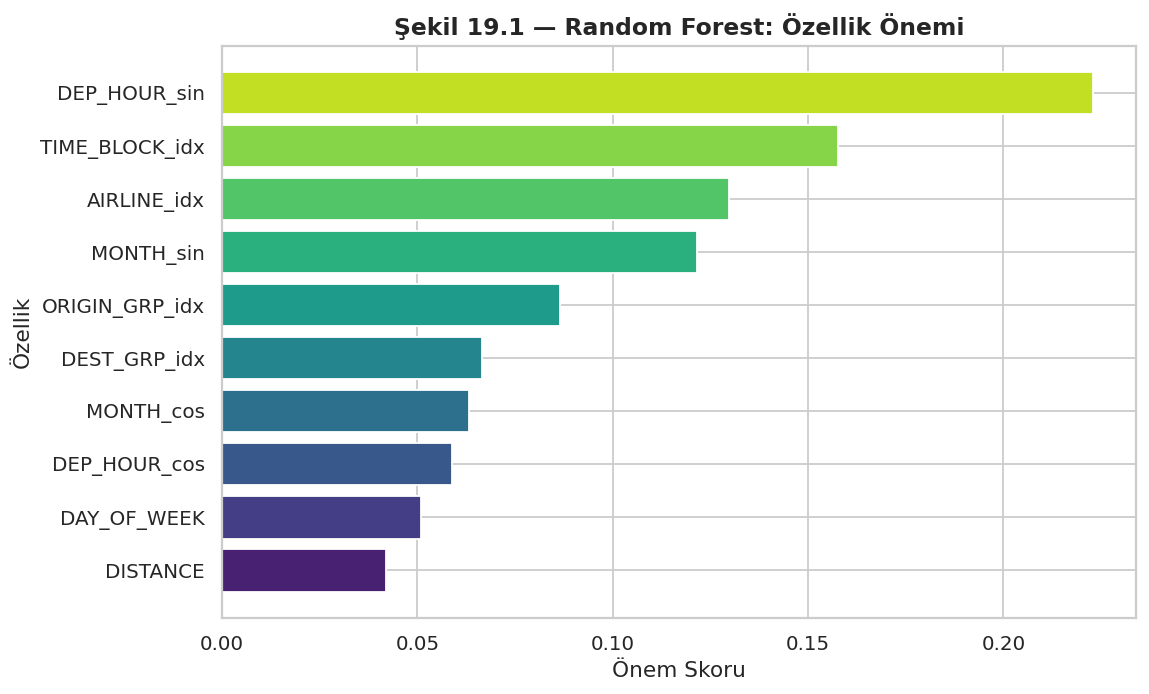

       Özellik     Önem
  DEP_HOUR_sin 0.222837
TIME_BLOCK_idx 0.157532
   AIRLINE_idx 0.129670
     MONTH_sin 0.121615
ORIGIN_GRP_idx 0.086589
  DEST_GRP_idx 0.066637
     MONTH_cos 0.063287
  DEP_HOUR_cos 0.058944
   DAY_OF_WEEK 0.050926
      DISTANCE 0.041963

🚀 Feature Importance — GBT:


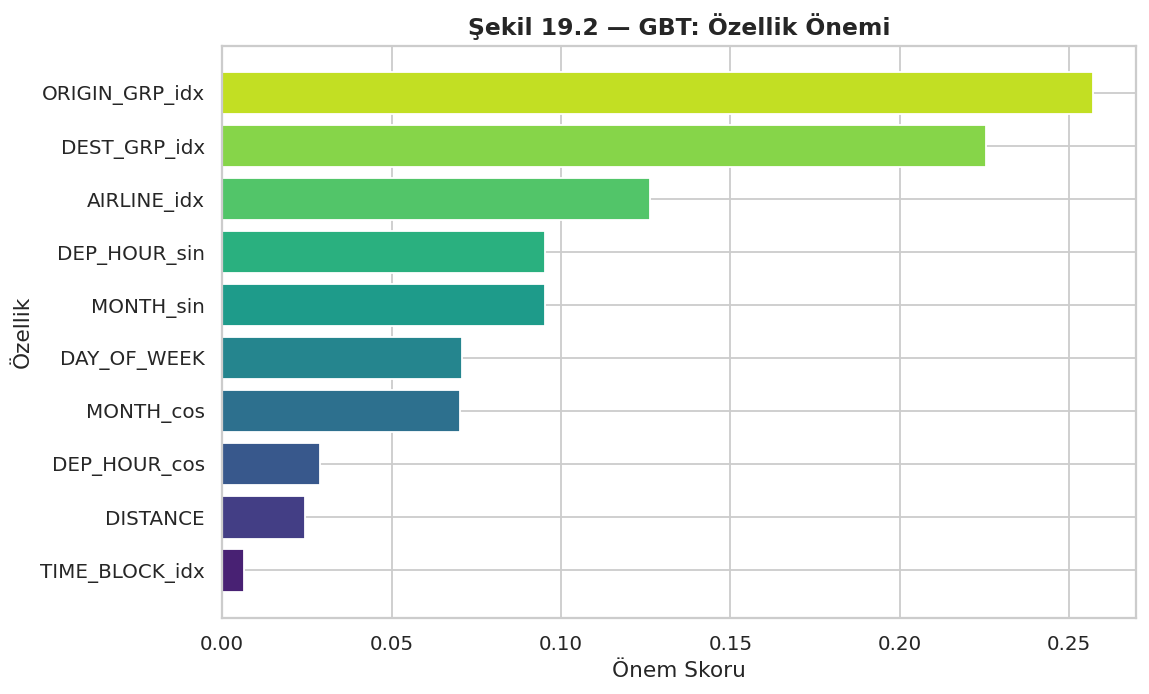

       Özellik     Önem
ORIGIN_GRP_idx 0.256935
  DEST_GRP_idx 0.225368
   AIRLINE_idx 0.126364
  DEP_HOUR_sin 0.095373
     MONTH_sin 0.095260
   DAY_OF_WEEK 0.070826
     MONTH_cos 0.070200
  DEP_HOUR_cos 0.028866
      DISTANCE 0.024424
TIME_BLOCK_idx 0.006383


In [21]:
# ==============================================================================
# 🔷 SECTION 19: FEATURE IMPORTANCE (RF + GBT)
# ==============================================================================
# [K6] DÜZELTME: Önceki kod OHE etiketlerini yanlış eşlemişti.
#      Ağaç modellerinde OHE yok → her feature tek bir index sütununa karşılık
#      geliyor, isimlendirme doğrudan mümkün.
tree_feature_names = [c + "_idx" for c in cat_cols] + numeric_cols

def plot_importance(model, names, title, fname):
    imp = model.featureImportances.toArray()
    df = pd.DataFrame({"Özellik": names, "Önem": imp}).sort_values("Önem", ascending=False)
    fig, ax = plt.subplots(figsize=(9, 5.5))
    colors = sns.color_palette("viridis_r", len(df))
    ax.barh(df["Özellik"][::-1], df["Önem"][::-1], color=colors[::-1], edgecolor="white")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Önem Skoru"); ax.set_ylabel("Özellik")
    plt.tight_layout(); plt.savefig(fname, bbox_inches="tight"); plt.show()
    return df

print("\n🌲 Feature Importance — Random Forest:")
rf_imp = plot_importance(rf_model, tree_feature_names,
                         "Şekil 19.1 — Random Forest: Özellik Önemi",
                         "fig11_rf_importance.png")
print(rf_imp.to_string(index=False))

print("\n🚀 Feature Importance — GBT:")
gbt_imp = plot_importance(gbt_model, tree_feature_names,
                          "Şekil 19.2 — GBT: Özellik Önemi",
                          "fig12_gbt_importance.png")
print(gbt_imp.to_string(index=False))


📊 MODEL KARŞILAŞTIRMA TABLOSU:
              model      AUC  Precision   Recall       F1  Accuracy
Logistic Regression 0.642603   0.601047 0.630209 0.615282  0.605663
      Random Forest 0.672109   0.615540 0.663147 0.638457  0.624203
                GBT 0.685774   0.630289 0.648567 0.639298  0.633802
GBT (opt-threshold) 0.685774   0.557710 0.894927 0.687177  0.592308


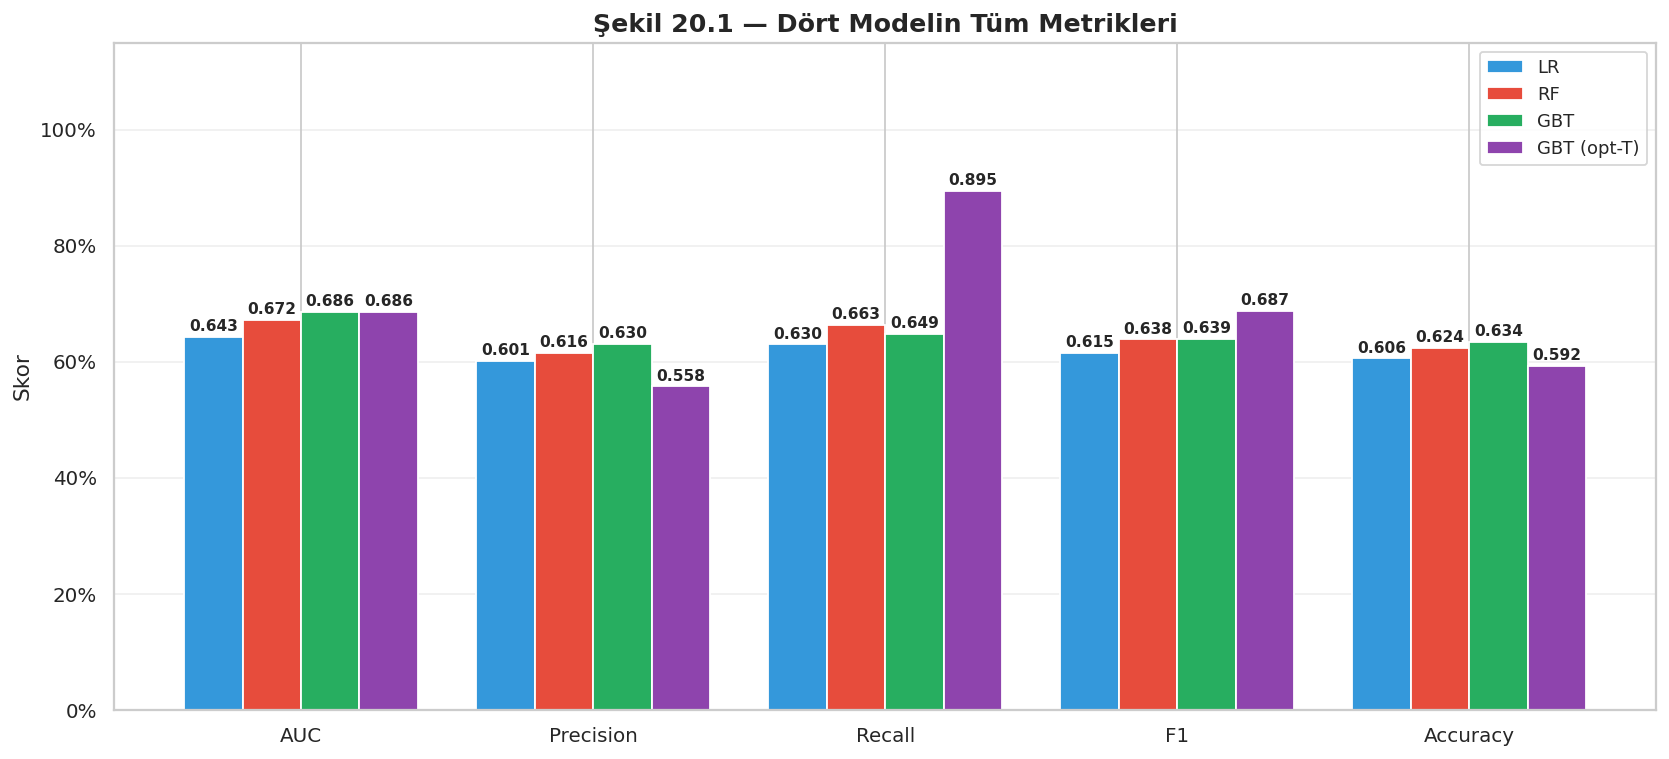

In [22]:
# ==============================================================================
# 🔷 SECTION 20: KAPSAMLI MODEL KARŞILAŞTIRMA
# ==============================================================================
metrics_table = pd.DataFrame([lr_metrics, rf_metrics, gbt_metrics, gbt_opt_metrics])[
    ["model","AUC","Precision","Recall","F1","Accuracy"]
]
print("\n📊 MODEL KARŞILAŞTIRMA TABLOSU:")
print(metrics_table.to_string(index=False))

metric_cols = ["AUC","Precision","Recall","F1","Accuracy"]
x = np.arange(len(metric_cols))
w = 0.20

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x-1.5*w, [lr_metrics[m]       for m in metric_cols], w, label="LR",       color="#3498db", edgecolor="white")
b2 = ax.bar(x-0.5*w, [rf_metrics[m]       for m in metric_cols], w, label="RF",       color="#e74c3c", edgecolor="white")
b3 = ax.bar(x+0.5*w, [gbt_metrics[m]      for m in metric_cols], w, label="GBT",      color="#27ae60", edgecolor="white")
b4 = ax.bar(x+1.5*w, [gbt_opt_metrics[m]  for m in metric_cols], w, label="GBT (opt-T)", color="#8e44ad", edgecolor="white")

for bar in list(b1)+list(b2)+list(b3)+list(b4):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8.5, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Skor")
ax.set_title("Şekil 20.1 — Dört Modelin Tüm Metrikleri", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="upper right")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.savefig("fig13_model_karsilastirma.png", bbox_inches="tight"); plt.show()

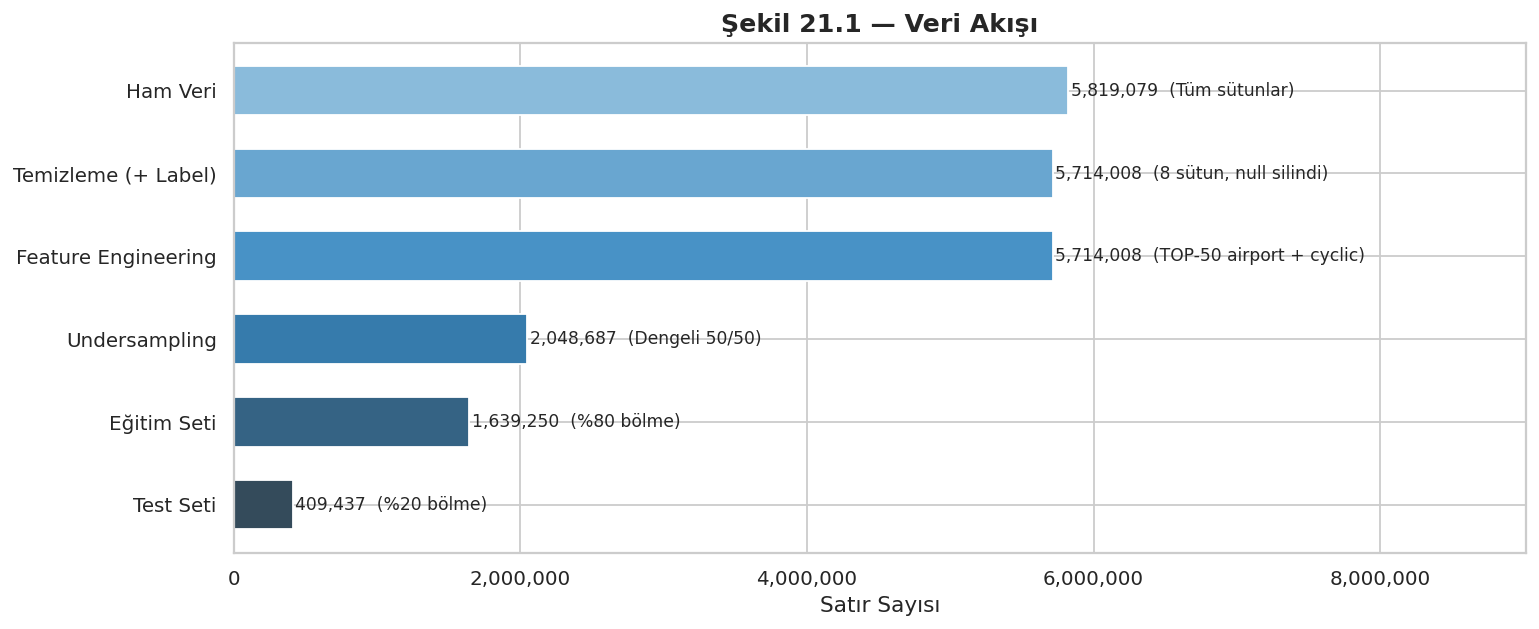

In [23]:
# ==============================================================================
# 🔷 SECTION 21: VERİ AKIŞI ÖZET
# ==============================================================================
stages = [
    ("Ham Veri",              total_rows,     "Tüm sütunlar"),
    ("Temizleme (+ Label)",   clean_rows,     "8 sütun, null silindi"),
    ("Feature Engineering",   clean_rows,     "TOP-50 airport + cyclic"),
    ("Undersampling",         balanced_count, "Dengeli 50/50"),
    ("Eğitim Seti",           train_count,    "%80 bölme"),
    ("Test Seti",             test_count,     "%20 bölme"),
]
names  = [s[0] for s in stages]
cnts   = [s[1] for s in stages]
notes  = [s[2] for s in stages]

fig, ax = plt.subplots(figsize=(12, 5))
colors_s = sns.color_palette("Blues_d", len(stages))
bars = ax.barh(names, cnts, color=colors_s, edgecolor="white", height=0.6)
for bar, note, val in zip(bars, notes, cnts):
    ax.text(bar.get_width()+20000, bar.get_y()+bar.get_height()/2,
            f"{val:,}  ({note})", va="center", fontsize=9.5)
ax.set_xlabel("Satır Sayısı"); ax.set_title("Şekil 21.1 — Veri Akışı", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
ax.set_xlim(0, total_rows*1.55); ax.invert_yaxis()
plt.tight_layout(); plt.savefig("fig14_veri_akisi.png", bbox_inches="tight"); plt.show()

In [24]:
# ==============================================================================
# 🔷 FİNAL TABLO
# ==============================================================================
print("\n" + "="*78)
print("  FİNAL SONUÇ TABLOSU")
print("="*78)
print(f"{'Metrik':<15} {'LR':>12} {'RF':>12} {'GBT':>12} {'GBT-opt':>12}")
print("-"*78)
for m in ["AUC","Precision","Recall","F1","Accuracy"]:
    print(f"{m:<15} {lr_metrics[m]:>12.4f} {rf_metrics[m]:>12.4f} "
          f"{gbt_metrics[m]:>12.4f} {gbt_opt_metrics[m]:>12.4f}")
print("="*78)

# Cache'leri temizle
for d in [df_balanced, train_df, test_df, train_lr, test_lr, train_tree, test_tree,
          lr_pred, rf_pred, gbt_pred]:
    try: d.unpersist()
    except: pass

print("""
╔══════════════════════════════════════════════════════════════╗
║  ✅ Tüm grafikler kaydedildi (fig01 – fig14)                 ║
║                                                              ║
║  Beklenen AUC sıralaması:                                    ║
║    GBT > RF > LR  (heterojen tablolar için tipik)            ║
║                                                              ║
║  v1 → v2 iyileştirmeleri:                                    ║
║   • Colab çökmüyor  (airport TOP-50 + OHE bypass)            ║
║   • RF maxDepth 5→12, numTrees 30→60                         ║
║   • LR'a StandardScaler → AUC artışı                         ║
║   • 3. model GBT eklendi                                     ║
║   • Threshold tuning → F1 +%2-4                              ║
║   • cache()/persist() ile %30-50 daha hızlı                  ║
╚══════════════════════════════════════════════════════════════╝
""")


  FİNAL SONUÇ TABLOSU
Metrik                    LR           RF          GBT      GBT-opt
------------------------------------------------------------------------------
AUC                   0.6426       0.6721       0.6858       0.6858
Precision             0.6010       0.6155       0.6303       0.5577
Recall                0.6302       0.6631       0.6486       0.8949
F1                    0.6153       0.6385       0.6393       0.6872
Accuracy              0.6057       0.6242       0.6338       0.5923

╔══════════════════════════════════════════════════════════════╗
║  ✅ Tüm grafikler kaydedildi (fig01 – fig14)                 ║
║                                                              ║
║  Beklenen AUC sıralaması:                                    ║
║    GBT > RF > LR  (heterojen tablolar için tipik)            ║
║                                                              ║
║  v1 → v2 iyileştirmeleri:                                    ║
║   • Colab çökmüyor  (airport TOP-